# TEE 실험 결과 분석

이 노트북은 CandyBox TEE(Trusted Execution Environment) 실험 결과를 분석합니다.

## 실험 매개변수
- **Server_Power**: 2, 4, 6 (cloud computation power)
- **Network**: 0, 30, 60, 90, 120 (network bandwidth)  
- **Workload**: 0.3, 0.5, 0.7, 0.9 (target utilization)
- **Algorithms**: CO-DMO-DT, CO-DMO, Offloading, DVS, Baseline

## 분석 목표
- 알고리즘별 성능 비교
- 파워 소모량 분석 (CPU, Memory, Network)
- 워크로드 및 네트워크 대역폭 영향 평가
- 최적 구성 식별

In [105]:
import pandas as pd

# CSV 파일로 저장 후 불러오기
df = pd.read_csv("simulators/experiment_results.csv")  # data.csv에 위의 데이터를 저장해두세요
df.head()


,Server_Power,Network,Workload,Section,Power,Util,CPU_Power,Memory_Power,Network_Power,Offloading_Ratio,CPU_Frequency_1,CPU_Frequency_0.5,CPU_Frequency_0.25,CPU_Frequency_0.125
0,2,10,0.3,CO-DMO-CT,3.096716,0.418372,0.833205,1.642125,0.621387,0.70,11,15,21,33
1,2,10,0.3,CO-DMO,3.346504,0.443601,1.224926,1.535512,0.586066,0.65,9,24,20,27
2,2,10,0.3,Offloading,11.385753,0.044925,3.223809,7.533286,0.628658,0.70,80,0,0,0
3,2,10,0.3,DVS,15.932699,0.999227,8.398733,7.533965,0.000000,0.00,9,34,26,11
4,2,10,0.3,Baseline,23.383182,0.299998,15.849895,7.533286,0.000000,0.00,80,0,0,0


In [106]:
# 데이터 크기와 컬럼
print(df.shape)
print(df.columns)

# 데이터 타입과 결측치
print(df.info())

# 데이터 통계 요약
df.describe()


(30, 14)
Index(['Server_Power', 'Network', 'Workload', 'Section', 'Power', 'Util',
       'CPU_Power', 'Memory_Power', 'Network_Power', 'Offloading_Ratio',
       'CPU_Frequency_1', 'CPU_Frequency_0.5', 'CPU_Frequency_0.25',
       'CPU_Frequency_0.125'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Server_Power         30 non-null     int64  
 1   Network              30 non-null     int64  
 2   Workload             30 non-null     float64
 3   Section              30 non-null     object 
 4   Power                30 non-null     float64
 5   Util                 30 non-null     float64
 6   CPU_Power            30 non-null     float64
 7   Memory_Power         30 non-null     float64
 8   Network_Power        30 non-null     float64
 9   Offloading_Ratio     30 non-null     float64
 10  CPU_Frequency_

,Server_Power,Network,Workload,Power,Util,CPU_Power,Memory_Power,Network_Power,Offloading_Ratio,CPU_Frequency_1,CPU_Frequency_0.5,CPU_Frequency_0.25,CPU_Frequency_0.125
count,30.0,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,2.0,65.000000,0.566667,18.308376,0.582078,12.511418,5.425948,0.371010,0.407917,44.333333,11.933333,11.800000,11.933333
std,0.0,55.940239,0.253708,16.194953,0.347095,14.709216,2.647512,0.585870,0.339219,33.305621,11.670574,11.324067,14.260951
min,2.0,10.000000,0.300000,2.512452,0.044925,0.760108,1.535512,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000
25%,2.0,10.000000,0.300000,5.118283,0.299998,2.154414,2.499239,0.000000,0.000000,10.250000,0.000000,0.000000,0.000000
50%,2.0,65.000000,0.500000,13.183185,0.604248,5.363563,7.533286,0.066278,0.650000,36.000000,11.500000,17.000000,1.000000
75%,2.0,120.000000,0.900000,25.803256,0.899982,18.269471,7.533859,0.612557,0.684375,80.000000,22.750000,21.000000,25.750000
max,2.0,120.000000,0.900000,53.082968,1.018162,45.549109,7.533965,1.885950,0.712500,80.000000,34.000000,28.000000,37.000000


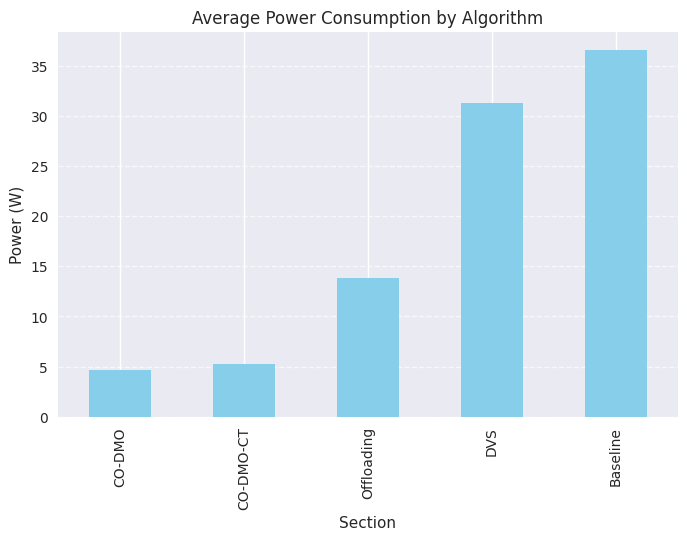

In [107]:
import matplotlib.pyplot as plt

avg_power = df.groupby("Section")["Power"].mean().sort_values()

plt.figure(figsize=(8,5))
avg_power.plot(kind="bar", color="skyblue")
plt.title("Average Power Consumption by Algorithm")
plt.ylabel("Power (W)")
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.show()


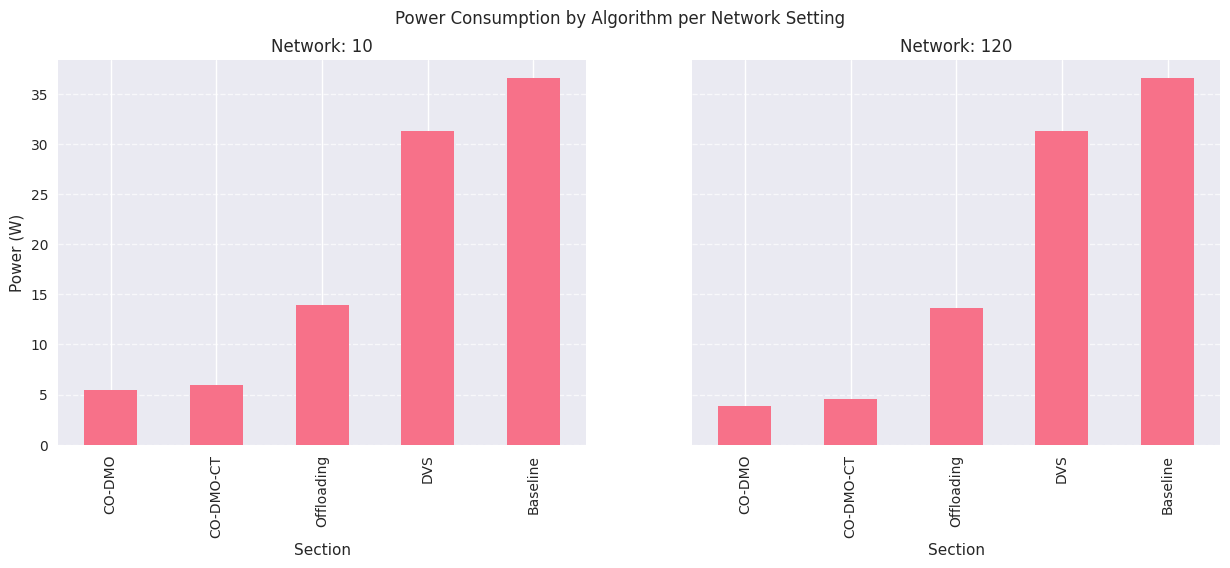

In [108]:
networks = sorted(df["Network"].unique())
fig, axes = plt.subplots(1, len(networks), figsize=(15,5), sharey=True)

for ax, net in zip(axes, networks):
    subset = df[df["Network"] == net]
    avg_power_net = subset.groupby("Section")["Power"].mean().sort_values()
    avg_power_net.plot(kind="bar", ax=ax)
    ax.set_title(f"Network: {net}")
    ax.set_ylabel("Power (W)")
    ax.grid(axis='y', linestyle="--", alpha=0.7)

plt.suptitle("Power Consumption by Algorithm per Network Setting")
plt.show()


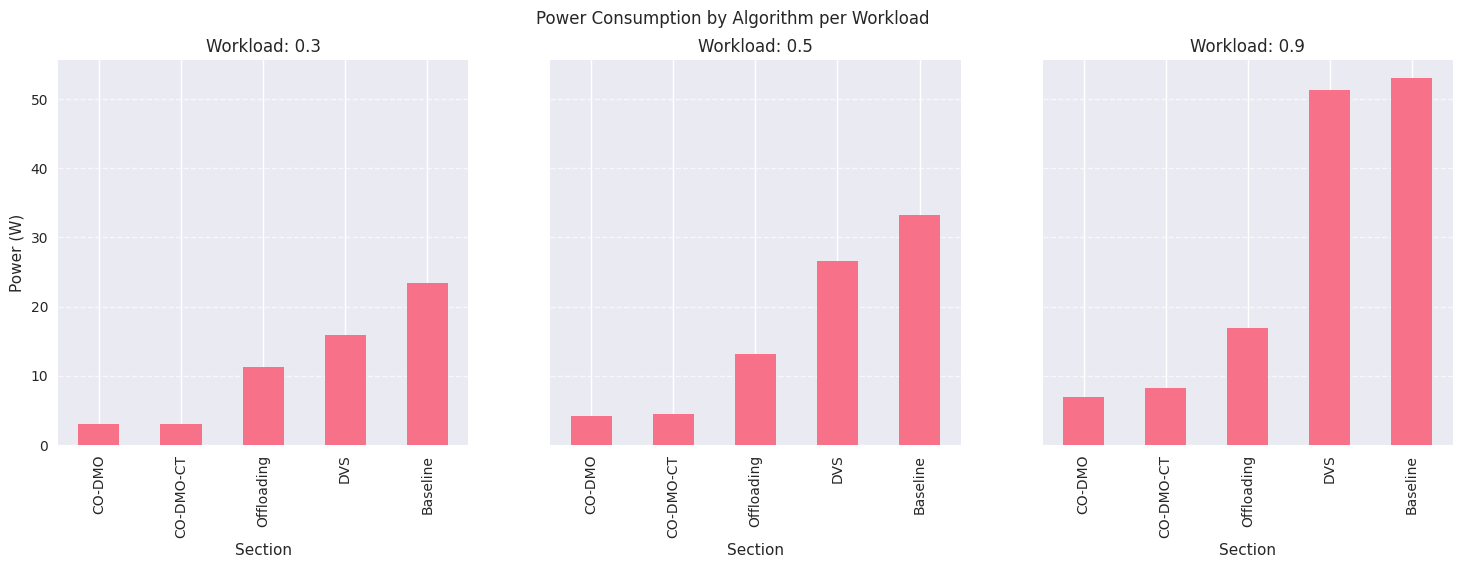

In [109]:
workloads = sorted(df["Workload"].unique())
fig, axes = plt.subplots(1, len(workloads), figsize=(18,5), sharey=True)

for ax, wl in zip(axes, workloads):
    subset = df[df["Workload"] == wl]
    avg_power_wl = subset.groupby("Section")["Power"].mean().sort_values()
    avg_power_wl.plot(kind="bar", ax=ax)
    ax.set_title(f"Workload: {wl}")
    ax.set_ylabel("Power (W)")
    ax.grid(axis='y', linestyle="--", alpha=0.7)

plt.suptitle("Power Consumption by Algorithm per Workload")
plt.show()


TypeError: 'Axes' object is not iterable

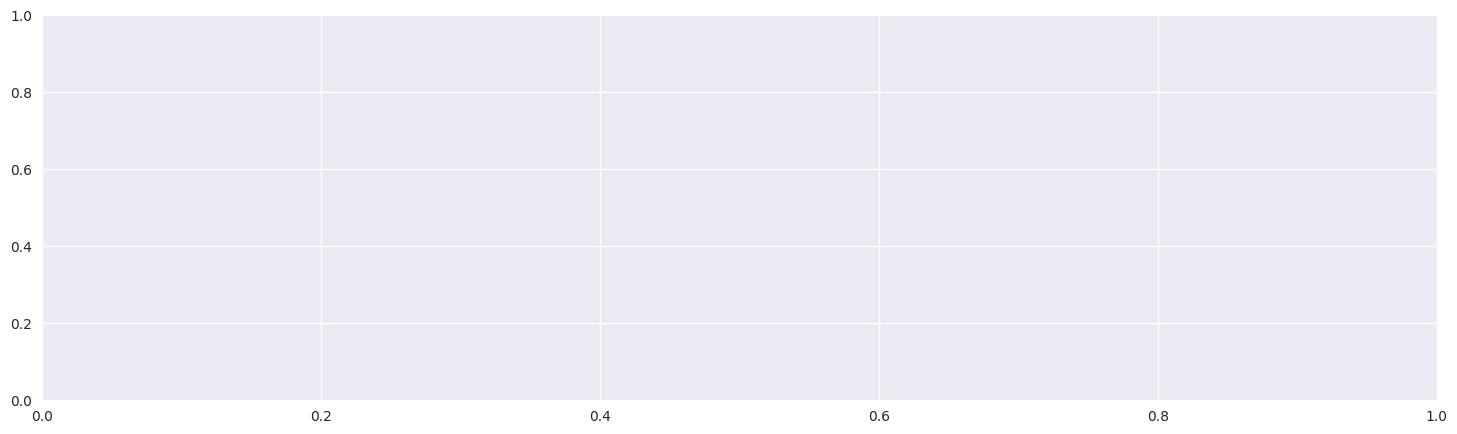

In [110]:
server_powers = sorted(df["Server_Power"].unique())
fig, axes = plt.subplots(1, len(server_powers), figsize=(18,5), sharey=True)

for ax, sp in zip(axes, server_powers):
    subset = df[df["Server_Power"] == sp]
    avg_power_sp = subset.groupby("Section")["Power"].mean().sort_values()
    avg_power_sp.plot(kind="bar", ax=ax)
    ax.set_title(f"Server Power: {sp}")
    ax.set_ylabel("Power (W)")
    ax.grid(axis='y', linestyle="--", alpha=0.7)

plt.suptitle("Power Consumption by Algorithm per Server Power")
plt.show()


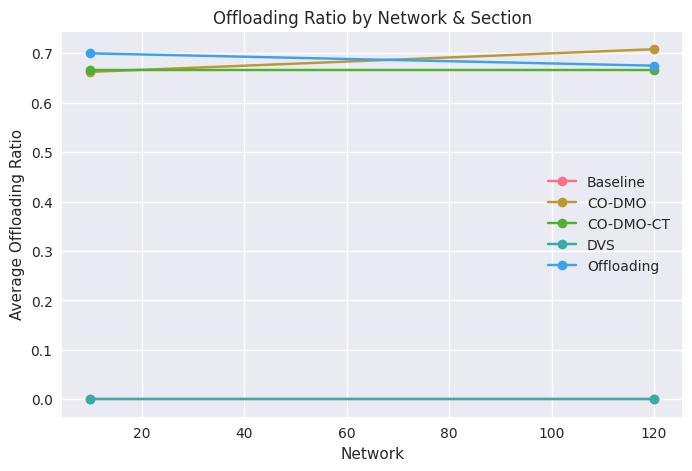

In [ ]:
offload_mean = df.groupby(["Network", "Section"])["Offloading_Ratio"].mean().reset_index()

plt.figure(figsize=(8, 5))
for sec in offload_mean["Section"].unique():
    subset = offload_mean[offload_mean["Section"] == sec]
    plt.plot(subset["Network"], subset["Offloading_Ratio"], marker='o', label=sec)

plt.xlabel("Network")
plt.ylabel("Average Offloading Ratio")
plt.title("Offloading Ratio by Network & Section")
plt.legend()
plt.grid(True)
plt.show()


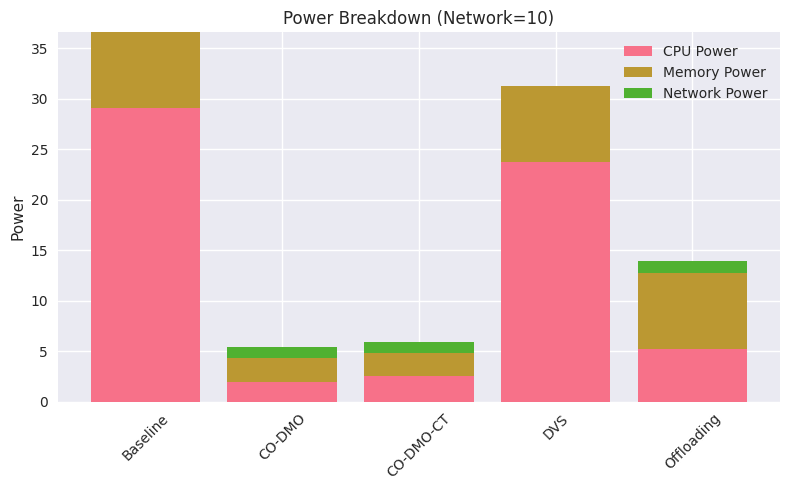

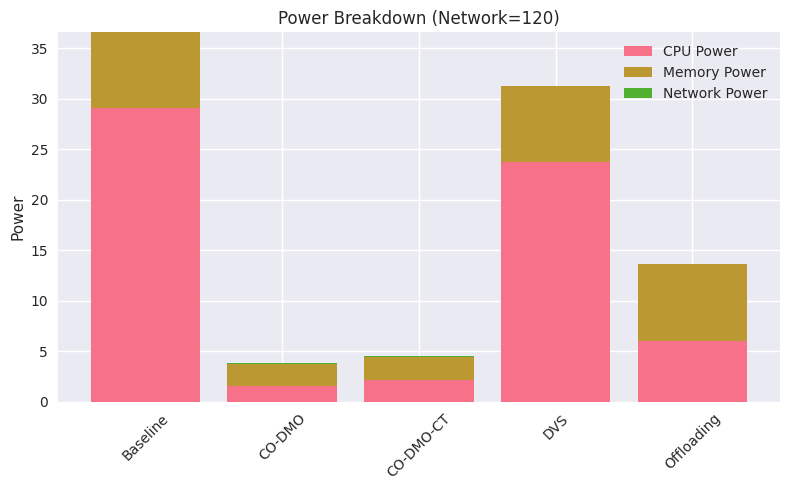

In [ ]:

# ------------------------------
# 3. Power 스택 그래프 (CPU/Memory/Network)
# ------------------------------
# 네트워크별 평균값
power_mean = df.groupby(["Network", "Section"])[["CPU_Power", "Memory_Power", "Network_Power"]].mean().reset_index()

networks = sorted(power_mean["Network"].unique())
sections = power_mean["Section"].unique()

for net in networks:
    subset = power_mean[power_mean["Network"] == net]
    plt.figure(figsize=(8, 5))
    plt.bar(subset["Section"], subset["CPU_Power"], label="CPU Power")
    plt.bar(subset["Section"], subset["Memory_Power"], bottom=subset["CPU_Power"], label="Memory Power")
    bottom_sum = subset["CPU_Power"] + subset["Memory_Power"]
    plt.bar(subset["Section"], subset["Network_Power"], bottom=bottom_sum, label="Network Power")

    plt.ylabel("Power")
    plt.title(f"Power Breakdown (Network={net})")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    Workload  Network     Section      Util
0        0.3       10    Baseline  0.299998
1        0.3       10      CO-DMO  0.443601
2        0.3       10   CO-DMO-CT  0.418372
3        0.3       10         DVS  0.999227
4        0.3       10  Offloading  0.044925
5        0.3      120    Baseline  0.299998
6        0.3      120      CO-DMO  0.271030
7        0.3      120   CO-DMO-CT  0.313628
8        0.3      120         DVS  0.999227
9        0.3      120  Offloading  0.054073
10       0.5       10    Baseline  0.499994
11       0.5       10      CO-DMO  0.758420
12       0.5       10   CO-DMO-CT  0.762116
13       0.5       10         DVS  0.994540
14       0.5       10  Offloading  0.074875
15       0.5      120    Baseline  0.499994
16       0.5      120      CO-DMO  0.452191
17       0.5      120   CO-DMO-CT  0.794432
18       0.5      120         DVS  0.994540
19       0.5      120  Offloading  0.090122
20       0.9       10    Baseline  0.899982
21       0.9       10      CO-DM

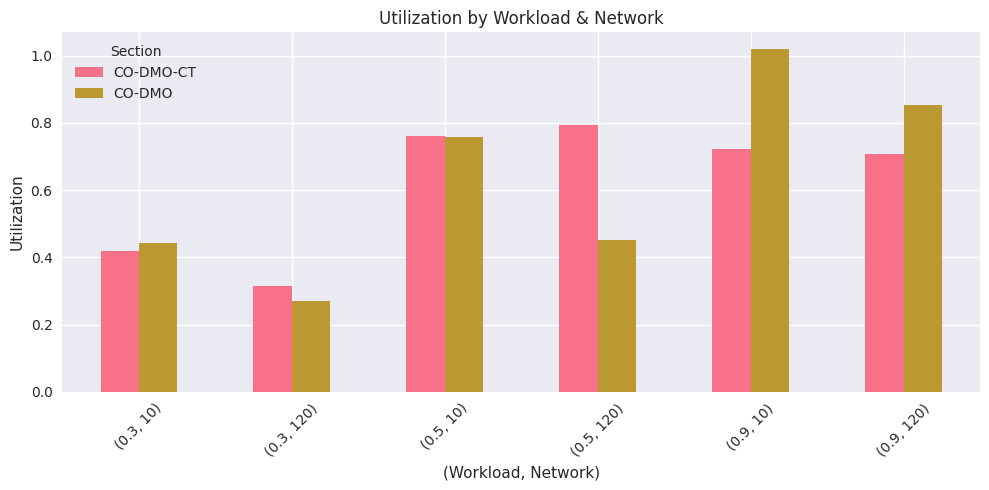

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

# Workload & Network별 Util 평균
util_wl_net = (
    df.groupby(["Workload", "Network", "Section"])["Util"]
      .mean()
      .reset_index()
      .sort_values(["Workload", "Network"])
)

print(util_wl_net)

# COD-MO-DT vs COD-MO만 필터링해서 비교
cod_util_wl_net = util_wl_net[util_wl_net["Section"].isin(["CO-DMO-CT", "CO-DMO"])]

# 피벗해서 비교 보기
pivot_cod = cod_util_wl_net.pivot_table(index=["Workload", "Network"], columns="Section", values="Util")
pivot_cod["Diff(COD-MO-CT - COD-MO)"] = pivot_cod["CO-DMO-CT"] - pivot_cod["CO-DMO"]

print(pivot_cod)

# 그래프: Workload/Network별 COD-MO-DT vs COD-MO Util
pivot_cod[["CO-DMO-CT", "CO-DMO"]].plot(kind="bar", figsize=(10,5))
plt.title("Utilization by Workload & Network")
plt.ylabel("Utilization")
plt.xlabel("(Workload, Network)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

